# Palace Field Visualization

Top-view and cross-section visualization of electromagnetic fields from a
Palace driven simulation on a CPW (coplanar waveguide) structure at 50 GHz.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Simulation setup

In [1]:
import gdsfactory as gf
from ihp import LAYER, PDK

from gsim.common.stack import get_stack
from gsim.palace import DrivenSim

PDK.activate()


@gf.cell
def gsg_electrode(
    length=300, s_width=20, g_width=40, gap_width=15, layer=LAYER.TopMetal2drawing
):
    c = gf.Component()
    r1 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r1.move((0, (g_width + s_width) / 2 + gap_width))
    _r2 = c << gf.c.rectangle((length, s_width), centered=True, layer=layer)
    r3 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r3.move((0, -(g_width + s_width) / 2 - gap_width))
    c.add_port(
        name="o1",
        center=(-length / 2, 0),
        width=s_width,
        orientation=180,
        port_type="electrical",
        layer=layer,
    )
    c.add_port(
        name="o2",
        center=(length / 2, 0),
        width=s_width,
        orientation=0,
        port_type="electrical",
        layer=layer,
    )
    return c


sim = DrivenSim()
sim.set_output_dir("./palace-sim-cpw-fields")
sim.set_geometry(gsg_electrode())

stack = get_stack(
    include_substrate=True, substrate_thickness=2.0
)  # auto-detects active PDK
sim.set_stack(stack)

sim.add_cpw_port("o1", layer="topmetal2", s_width=20, gap_width=15)
sim.add_cpw_port("o2", layer="topmetal2", s_width=20, gap_width=15)

# Single frequency point at 50 GHz, adaptive off so Palace does a full solve
sim.set_driven(
    fmin=50e9,
    fmax=50e9 + 1e6,  # tiny range = effectively one point
    num_points=1,
    adaptive_tol=0,
    save_step=1,
)
sim.set_airbox(margin_x=50, margin_y=0, z_above=100, z_below=100)
sim.mesh(
    preset="default",
    refined_mesh_size=2.0,
    max_mesh_size=25.0,
)

Mesh Summary
Dimensions: 500.0 x 130.0 x 218.3 µm
Nodes:      14,464
Elements:   106,347
Tetrahedra: 76,621
Edge length: 0.40 - 50.03 µm
Quality:    0.582 (min: 0.010)
SICN:       0.625 (all valid)
----------------------------------------
Volumes (4):
  - silicon [1]
  - SiO2 [2]
  - passive [3]
  - air [4]
Surfaces (15):
  - topmetal2_xy [5]
  - topmetal2_z [6]
  - P1_E0 [7]
  - P1_E1 [8]
  - P2_E0 [9]
  - P2_E1 [10]
  - air__silicon [11]
  - silicon__None [12]
  - SiO2__silicon [13]
  - SiO2__air [14]
  - SiO2__None [15]
  - SiO2__passive [16]
  - air__passive [17]
  - passive__None [18]
  - air__None [19]
----------------------------------------
Mesh:   palace-sim-cpw-fields/palace.msh

### Load results

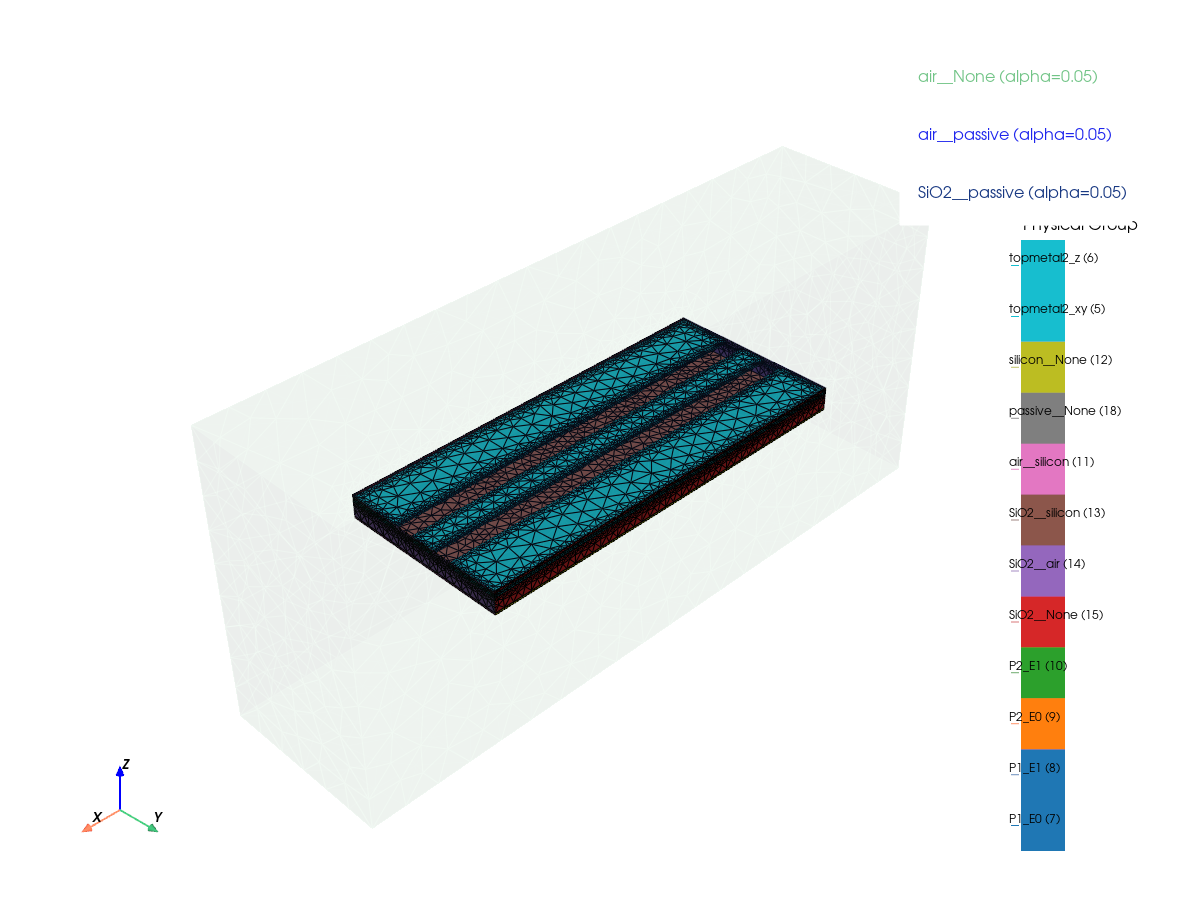

In [2]:
sim.plot_mesh(
    show_groups=["metal", "P", "via"],
    style="solid",
    transparent_groups=["air__None", "air__passive", "SiO2__passive"],
)

In [3]:
results = sim.run()

  palace-d945f4f6  completed  0m 59s


Extracting results.tar.gz...


Downloaded 29 files to sim-data-palace-d945f4f6


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from mpl_toolkits.axes_grid1 import make_axes_locatable

from gsim.palace import load_fields
from gsim.viz import plot_cross_section, plot_topview

pv.OFF_SCREEN = True

# Get results dir from sim output (or hardcode for re-runs)
results_dir = Path(results.files["port-S.csv"]).parent
print(f"Results dir: {results_dir}")

# Read frequency from S-parameter CSV (first data row, first column)
s_csv = np.loadtxt(results_dir / "port-S.csv", delimiter=",", skiprows=1)
freq_ghz = s_csv[0, 0]

vol = load_fields(results_dir, excitation=1)
bnd = load_fields(results_dir, excitation=1, boundary=True)

print(f"Frequency: {freq_ghz:.1f} GHz")
print(f"Volume: {vol.n_points:,} points, {vol.n_cells:,} cells")
print(f"Boundary: {bnd.n_points:,} points, {bnd.n_cells:,} cells")

Results dir: output


Frequency: 50.0 GHz
Volume: 766,210 points, 76,621 cells
Boundary: 223,632 points, 37,272 cells


### Top view at conductor layer

In [5]:
# Slice volume at conductor top
z_conductor = 16.0
vol_slice = vol.slice(normal="z", origin=(0, 0, z_conductor))

# Map physical group names from palace.msh -> boundary attribute IDs
import meshio

msh_path = results_dir.parent.parent / "results" / "input" / "palace.msh"
mio = meshio.read(msh_path)
topmetal2_attr = [
    int(tag)
    for name, (tag, _dim) in mio.field_data.items()
    if "topmetal2_xy" in name.lower()
]

if not topmetal2_attr:
    raise ValueError(
        f"Could not find 'topmetal2_xy' in physical groups of {msh_path}. "
        f"Available: {sorted(mio.field_data.keys())}"
    )

print(f"Using topmetal2_xy attributes for J_s_real: {topmetal2_attr}")

Using topmetal2_xy attributes for J_s_real: [5]


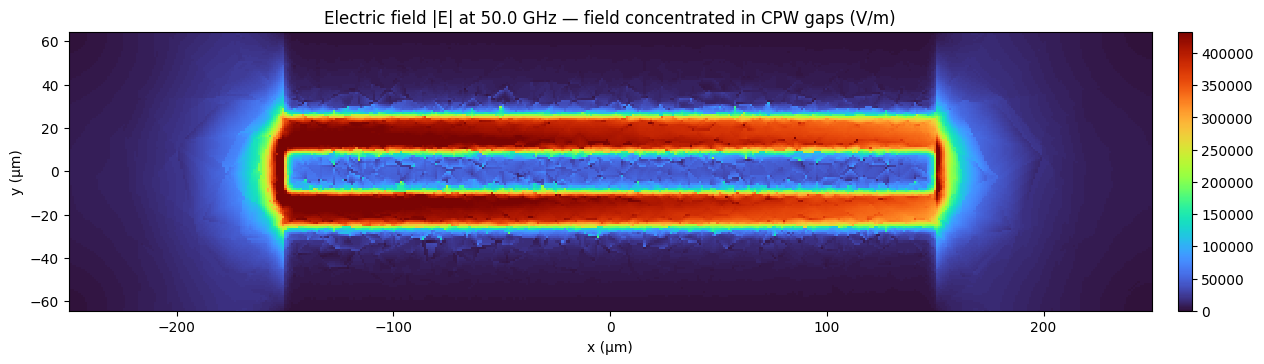

In [6]:
plot_topview(
    vol,
    field="E_real",
    z=z_conductor,
    title=f"Electric field |E| at {freq_ghz:.1f} GHz — field concentrated in CPW gaps (V/m)",
)

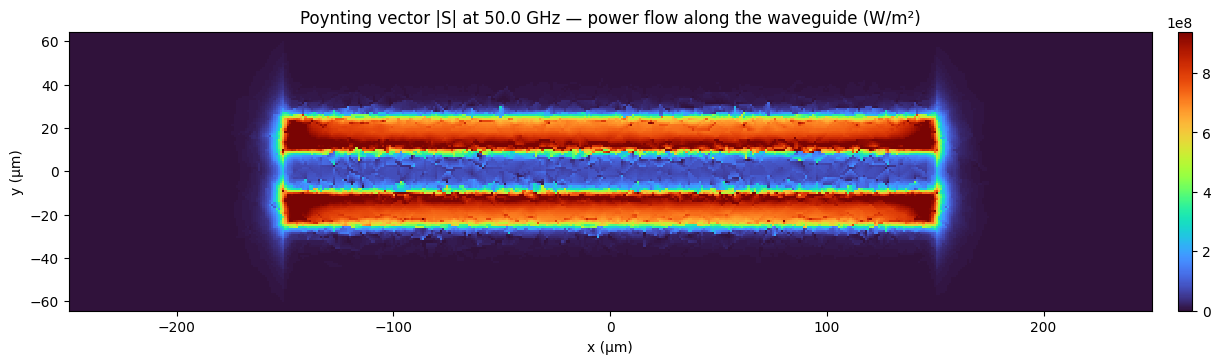

In [7]:
plot_topview(
    vol,
    field="S",
    z=z_conductor,
    title=f"Poynting vector |S| at {freq_ghz:.1f} GHz — power flow along the waveguide (W/m²)",
)

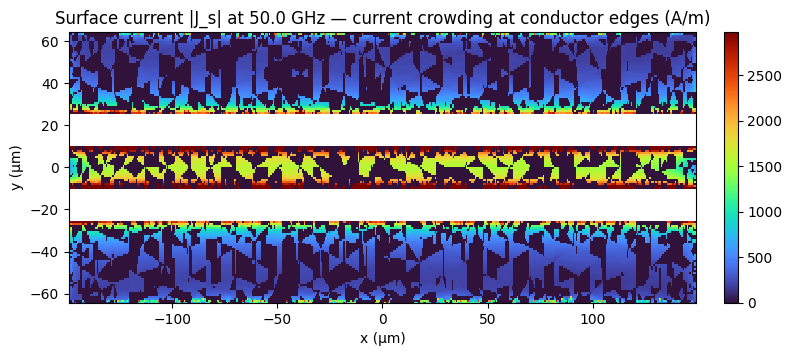

In [8]:
plot_topview(
    bnd,
    field="J_s_real",
    z=16.3,
    attribute_values=topmetal2_attr,
    snap_to_closest_point=True,
    surface_direct=False,
    title=f"Surface current |J_s| at {freq_ghz:.1f} GHz — current crowding at conductor edges (A/m)",
)

### Field components — top view

`E_y` is the dominant E-field component in a CPW — the transverse field across
the gaps between signal and ground. A diverging colormap shows the polarity
flipping between the two gaps, which the magnitude plots above hide.

In [9]:
# Surface-current top view now uses automatic material-aware filtering
# inside gsim.viz.plot_topview (no manual attribute filter needed).

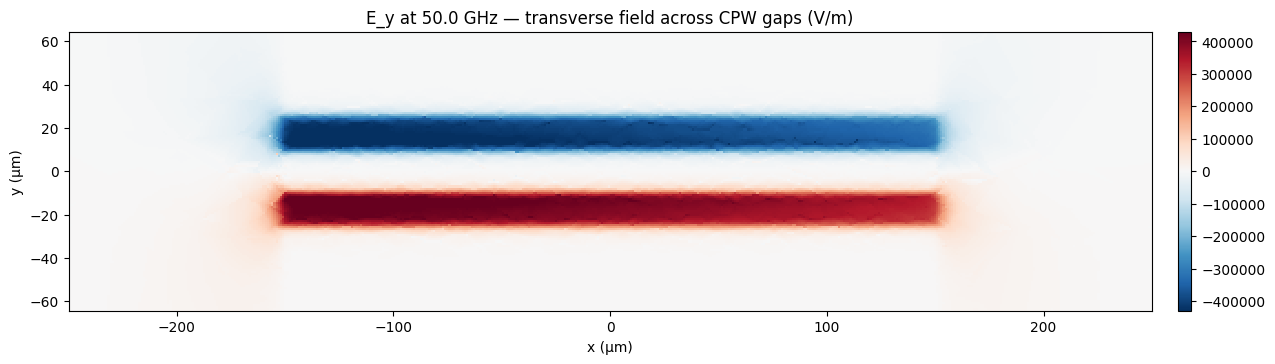

In [10]:
plot_topview(
    vol,
    field="E_real",
    component=1,
    z=z_conductor,
    title=f"E_y at {freq_ghz:.1f} GHz — transverse field across CPW gaps (V/m)",
    cmap="RdBu_r",
    symmetric=True,
)

### Cross-sections (YZ plane at x=0)

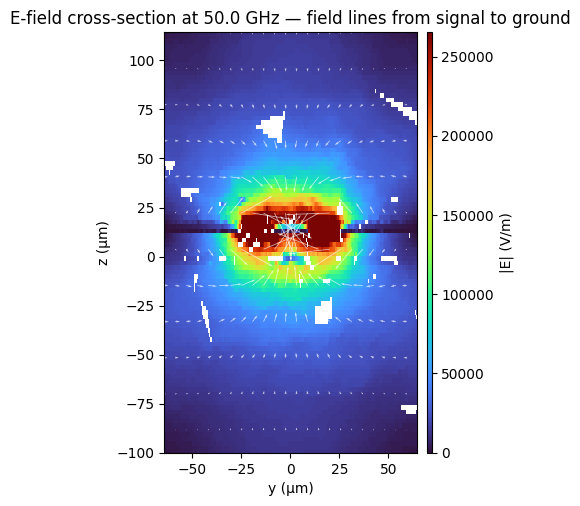

In [11]:
yz_slice = vol.slice(normal="x", origin=(0, 0, 0))
yz_pts = yz_slice.points

plot_cross_section(
    vol,
    normal="x",
    origin=0,
    field="E_real",
    title=f"E-field cross-section at {freq_ghz:.1f} GHz — field lines from signal to ground",
    label="|E| (V/m)",
)

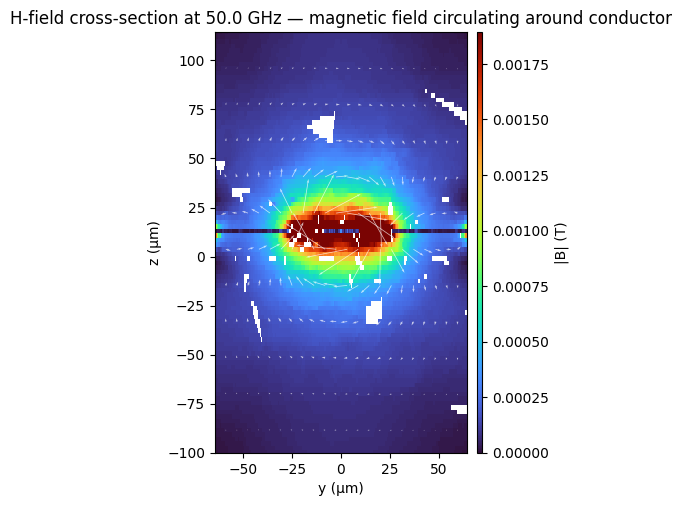

In [12]:
plot_cross_section(
    vol,
    normal="x",
    origin=0,
    field="B_real",
    title=f"H-field cross-section at {freq_ghz:.1f} GHz — magnetic field circulating around conductor",
    label="|B| (T)",
)

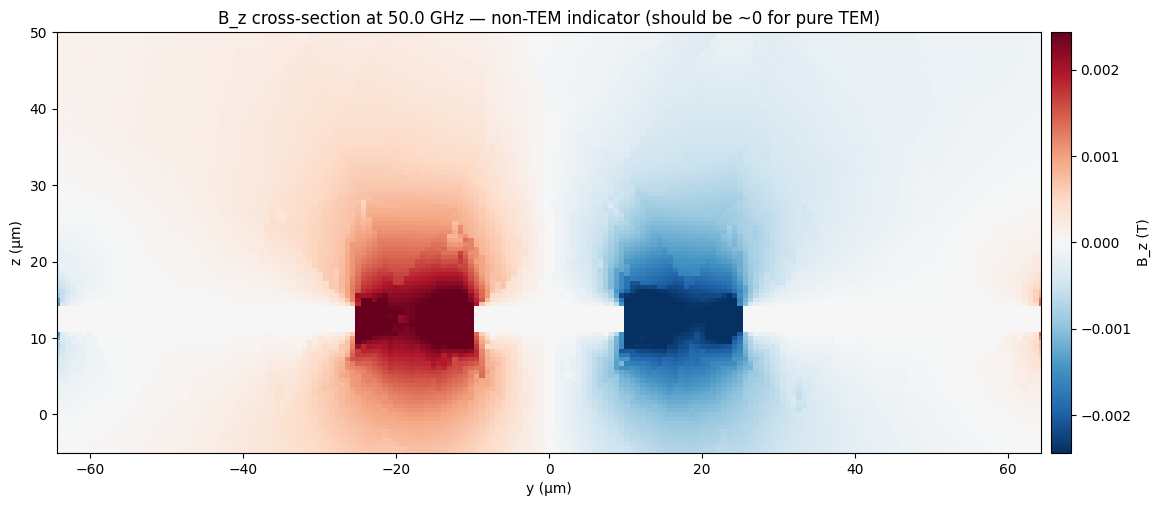

In [13]:
# B_z component cross-section — non-zero B_z indicates departure from pure TEM mode
y_pad = 5
yz_slice = vol.slice(normal="x", origin=(0, 0, 0))
yz_pts = yz_slice.points

yi_cs = np.linspace(yz_pts[:, 1].min() - y_pad, yz_pts[:, 1].max() + y_pad, 200)
zi_cs = np.linspace(-5, 50, 100)
Yi_cs, Zi_cs = np.meshgrid(yi_cs, zi_cs)

Xi_cs = np.zeros_like(Yi_cs)
probe_cs = pv.StructuredGrid(Xi_cs, Yi_cs, Zi_cs)
sampled_cs = probe_cs.sample(vol)

if "B_real" not in sampled_cs.point_data:
    raise ValueError(
        f"Field 'B_real' not found in sampled data. Available: {list(sampled_cs.point_data.keys())}"
    )

Bz_cs = sampled_cs.point_data["B_real"][:, 2].reshape(Yi_cs.shape, order="F")
if "vtkValidPointMask" in sampled_cs.point_data:
    valid_cs = (
        sampled_cs.point_data["vtkValidPointMask"]
        .astype(bool)
        .reshape(
            Yi_cs.shape,
            order="F",
        )
    )
    Bz_cs = np.where(valid_cs, Bz_cs, np.nan)

fig, ax = plt.subplots(figsize=(12, 5))
vlim = np.nanpercentile(np.abs(Bz_cs), 98)
im = ax.pcolormesh(
    Yi_cs, Zi_cs, Bz_cs, cmap="RdBu_r", shading="auto", vmin=-vlim, vmax=vlim
)
ax.set_title(
    f"B_z cross-section at {freq_ghz:.1f} GHz — non-TEM indicator (should be ~0 for pure TEM)"
)
ax.set_xlabel("y (µm)")
ax.set_ylabel("z (µm)")
ax.set_aspect("equal")
valid = ~np.isnan(Bz_cs)
if valid.any():
    rows = np.any(valid, axis=1)
    cols = np.any(valid, axis=0)
    ax.set_xlim(yi_cs[cols][0], yi_cs[cols][-1])
    ax.set_ylim(zi_cs[rows][0], zi_cs[rows][-1])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.1)
fig.colorbar(im, cax=cax, label="B_z (T)")
fig.tight_layout(pad=0.5)
plt.show()